<h1 style="color:dodgerblue; font-size:50px; text-align:center;">
Employee Attrition Prediction and Workforce Strategy Optimization
</h1>

<h3 style="color:white; text-align:center;">
Machine Learning, Workforce Analytics, and Strategic Retention Intelligence
</h3>

<hr style="border:2px solid gray">

<h1 style="color:green">1. Requirements</h1>

In [1]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


<hr style="border:2px solid gray">

<h1 style="color:green">2. Data Preparation and Exploratory Analysis</h1>

<h1 style="color:cyan">2.1 Importing Libraries</h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# =========================
# Create Clean requirements.txt
# =========================

required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "scipy",
    "jupyter"
]

with open("requirements_clean_updated.txt", "w") as f:
    for package in required_packages:
        f.write(package + "\n")

print("Clean requirements file created: requirements_clean_updated.txt")

Clean requirements file created: requirements_clean_updated.txt


<h1 style="color:cyan">2.2 Load dataset</h1>

In [4]:
import pandas as pd
df = pd.read_csv('C:/Users/ninja/OneDrive/Documents/Attrition and Hiring/data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

<h1 style="color:cyan">2.3 Basic inspection</h1>

In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


<h1 style="color:cyan">2.4 Target variable</h1>

In [8]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [10]:
print(df['Attrition'].unique())

[1 0]


In [11]:
print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


<h1 style="color:cyan">2.5 Drop Useless columns</h1>

In [12]:
df.drop(['EmployeeCount','Over18','StandardHours','EmployeeNumber'], axis=1, inplace=True)

<h1 style="color:cyan">2.6 Check missing values</h1>

In [13]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

<h1 style="color:cyan">2.7 Calculate Attrition Rate</h1>

In [14]:
attrition_rate = df['Attrition'].mean()
print("Attrition Rate:", attrition_rate)

Attrition Rate: 0.16122448979591836


<h6 style="color:yellow">The dataset contains employee-level information. Attrition is the target variable, where 1 indicates an employee leaving the company. The observed attrition rate is approximately X%, indicating a moderate retention challenge.</h6>

<hr style="border:2px solid gray">

<h1 style="color:green">3.  Data Transformation</h1>

<h1 style="color:cyan">3.1 Set style</h1>

In [15]:
sns.set(style="darkgrid")

<h1 style="color:cyan">3.2 Attrition Distribution</h1>

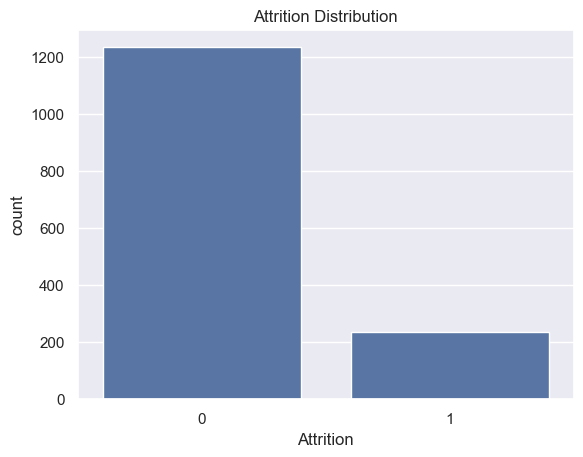

In [16]:
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

<h6 style="color:yellow">The dataset shows an imbalanced distribution, with fewer employees leaving compared to staying, which will influence model selection and evaluation</h6>

<h1 style="color:cyan">3.3 Hypothesis-driven analysis</h1>
<h2 style="color:white">Hypothesis 1: Overtime increases attrition</h2>


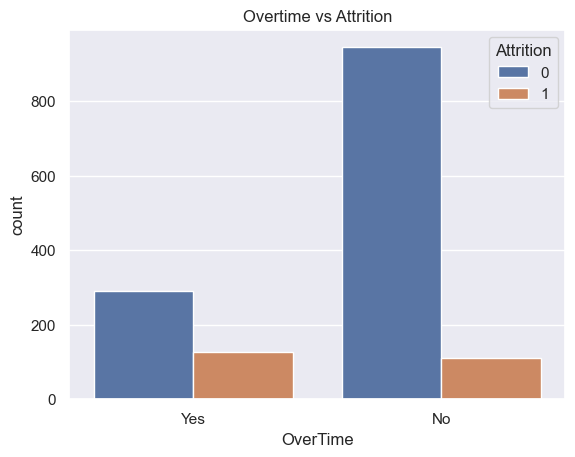

In [17]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Overtime vs Attrition")
plt.show()

<h2 style="color:white">Hypothesis 2: Income impacts attrition</h2>

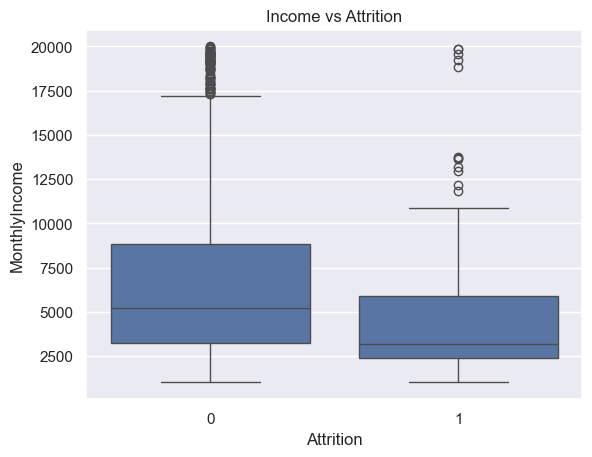

In [18]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Income vs Attrition")
plt.show()

<h2 style="color:white">Hypothesis 3: Tenure Matters</h2>

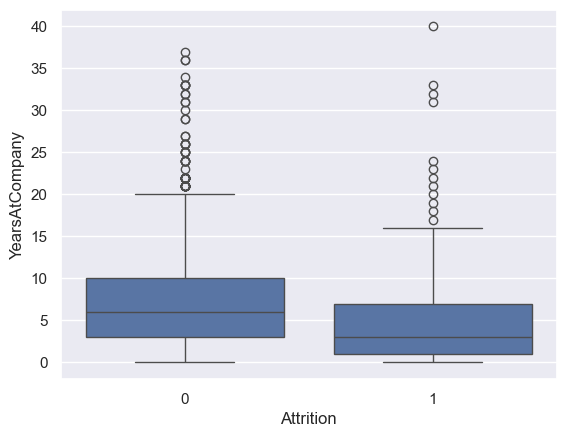

In [19]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.show()


<h2 style="color:white">Key Insights from Analysis</h2>
<h6 style="color:yellow">

<ul style="color:yellow">

<li>Employees working overtime have significantly higher attrition rates, indicating workload-driven burnout</li>

<li>Employees in early tenure (0–2 years) are more likely to leave, highlighting onboarding gaps</li>

<li>Lower monthly income correlates with higher attrition, suggesting compensation dissatisfaction</li>

<li>Job satisfaction and work-life balance play critical roles in retention</li>

</ul>

</h6>

<h1 style="color:cyan">3.4 Correleation Heatmap</h1>

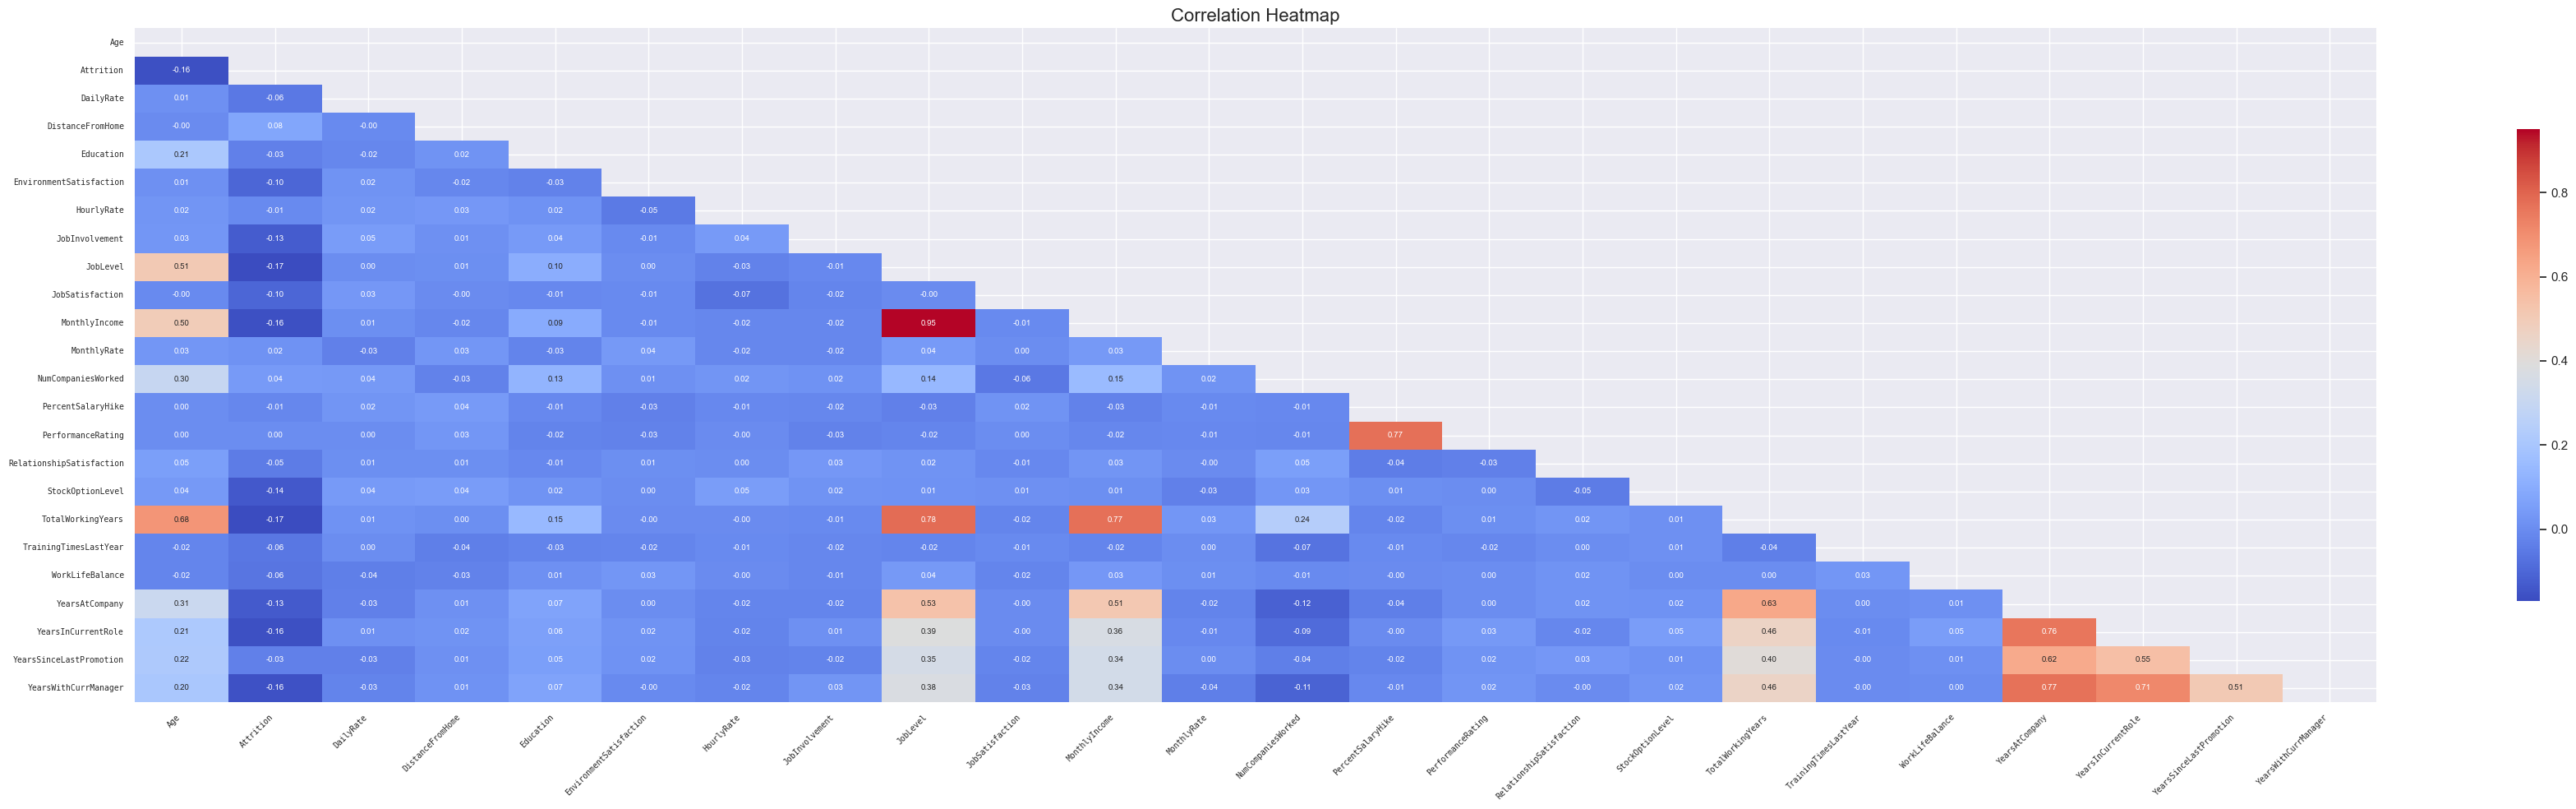

In [20]:
num_df = df.select_dtypes(include=[np.number])

num_cols = len(num_df.columns)

plt.figure(figsize=(max(num_cols * 1.5, 16), 10))

mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))

sns.heatmap(
    num_df.corr(),
    mask=mask,
    cmap='coolwarm',
    square=False,
    annot=True,
    fmt='.2f',
    annot_kws={'size':7},
    cbar_kws={'shrink':0.7}
)

plt.title("Correlation Heatmap", fontsize=16)

plt.xticks(
    fontsize=7,
    fontname='monospace',
    rotation=45,
    ha='right'
)

plt.yticks(
    fontsize=7,
    fontname='monospace'
)

plt.tight_layout()

plt.show()

<h6 style="color:yellow">The correlation heatmap highlights relationships between numerical variables. While most features show weak linear correlations with attrition, variables such as monthly income, years at company, and total working years exhibit meaningful relationships with each other. This suggests that attrition is influenced by a combination of factors rather than a single dominant variable, reinforcing the need for multivariate modeling.</h6>

<hr style="border:2px solid gray">

<h1 style="color:green">4. Feature Engineering</h1>
<h2 style="color:white">Create new features</h2>


In [21]:
df['TenureGroup'] = pd.cut(df['YearsAtCompany'], bins=[0,2,5,10,40], labels=['0-2','2-5','5-10','10+'])

df['IncomePerYear'] = df['MonthlyIncome'] * 12

<h2 style="color:white">Encode categorical variables properly</h2>

In [22]:
df = pd.get_dummies(df, drop_first=True)

<hr style="border:2px solid gray">

<h1 style="color:green">5. Handle Imbalance</h1>

In [23]:
from sklearn.utils import resample

df_majority = df[df.Attrition==0]
df_minority = df[df.Attrition==1]

df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

<hr style="border:2px solid gray">

<h1 style="color:green">6. Models</h1>


In [24]:
from sklearn.model_selection import train_test_split

X = df_balanced.drop('Attrition', axis=1)
y = df_balanced['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h2 style="color:white">Model 1: Logistic Regression</h2>

In [25]:
# =========================
# 1. Import required modules
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report



# =========================
# 2. Define features & target
# =========================
X = df_balanced.drop('Attrition', axis=1)
y = df_balanced['Attrition']


# =========================
# 3. Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 4. Feature scaling
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================
# 5. Model training
# =========================
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

model.fit(X_train_scaled, y_train)


# =========================
# 6. Predictions
# =========================
y_pred = model.predict(X_test_scaled)


# =========================
# 7. Evaluation
# =========================
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       248
           1       0.79      0.83      0.81       246

    accuracy                           0.81       494
   macro avg       0.81      0.81      0.81       494
weighted avg       0.81      0.81      0.81       494



In [26]:

# =========================
# 8. Confusion Matrix
# =========================
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[193  55]
 [ 41 205]]


In [27]:

# =========================
# 9. ROC-AUC Score
# =========================
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))



ROC-AUC: 0.8705579596118542


In [28]:

# =========================
# 10. Feature Importance
# =========================
import pandas as pd

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coeff_df.head(10))



                              Feature  Coefficient
19                     YearsAtCompany     1.200945
44                       OverTime_Yes     0.943553
35      JobRole_Laboratory Technician     0.758145
24   BusinessTravel_Travel_Frequently     0.753643
41       JobRole_Sales Representative     0.690797
27                   Department_Sales     0.669942
34            JobRole_Human Resources     0.665445
26  Department_Research & Development     0.608952
43               MaritalStatus_Single     0.595283
40            JobRole_Sales Executive     0.546641


In [29]:

# =========================
# 10. Cross Validation
# =========================

from sklearn.model_selection import cross_val_score

X_scaled = scaler.fit_transform(X)

lr_cv_scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5,
    scoring='roc_auc'
)

print("LR CV Scores:", lr_cv_scores)
print("LR Mean ROC-AUC:", lr_cv_scores.mean())



LR CV Scores: [0.85656215 0.86786149 0.87850959 0.85398769 0.86623218]
LR Mean ROC-AUC: 0.8646306216049424


In [30]:
# =========================
# 11 .Hyperparameter Tuning 
# =========================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 10}
Best CV Score: 0.8640962173982866


In [31]:
# =========================
# 12. Evaluate Tuned Logistic Regression
# =========================

best_lr = grid.best_estimator_

y_prob_lr_tuned = best_lr.predict_proba(X_test_scaled)[:,1]

print("Test ROC-AUC (Tuned LR):", roc_auc_score(y_test, y_prob_lr_tuned))

Test ROC-AUC (Tuned LR): 0.8705251770259639


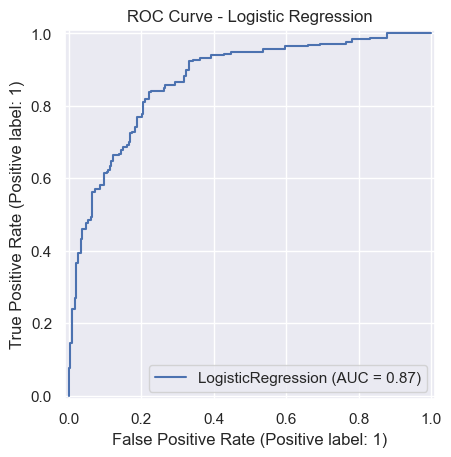

In [32]:
# =========================
# 13. ROC Curve
# =========================

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [33]:
# =========================
# 14. Improved Feature Importance
# =========================

import pandas as pd

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coeff_df['Abs_Coefficient'] = coeff_df['Coefficient'].abs()
coeff_df = coeff_df.sort_values(by='Abs_Coefficient', ascending=False)

print(coeff_df.head(10))

                              Feature  Coefficient  Abs_Coefficient
19                     YearsAtCompany     1.200945         1.200945
44                       OverTime_Yes     0.943553         0.943553
35      JobRole_Laboratory Technician     0.758145         0.758145
24   BusinessTravel_Travel_Frequently     0.753643         0.753643
41       JobRole_Sales Representative     0.690797         0.690797
27                   Department_Sales     0.669942         0.669942
34            JobRole_Human Resources     0.665445         0.665445
47                    TenureGroup_10+    -0.611039         0.611039
26  Department_Research & Development     0.608952         0.608952
43               MaritalStatus_Single     0.595283         0.595283


In [34]:
# =========================
# 15. Logistic Regression with Class Weight
# =========================

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

model_balanced.fit(X_train_scaled, y_train)

y_prob_bal = model_balanced.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import roc_auc_score
print("ROC-AUC (Balanced Model):", roc_auc_score(y_test, y_prob_bal))

ROC-AUC (Balanced Model): 0.8705743509047995


In [35]:
# =========================
# 16. Features increasing attrition risk
# =========================
high_risk = coeff_df.sort_values(by='Coefficient', ascending=False).head(5)

# =========================
# 17. Features decreasing attrition risk
# =========================
low_risk = coeff_df.sort_values(by='Coefficient').head(5)

print("Top Attrition Drivers:\n", high_risk[['Feature','Coefficient']])
print("\nRetention Drivers:\n", low_risk[['Feature','Coefficient']])

Top Attrition Drivers:
                              Feature  Coefficient
19                    YearsAtCompany     1.200945
44                      OverTime_Yes     0.943553
35     JobRole_Laboratory Technician     0.758145
24  BusinessTravel_Travel_Frequently     0.753643
41      JobRole_Sales Representative     0.690797

Retention Drivers:
                     Feature  Coefficient
47          TenureGroup_10+    -0.611039
16        TotalWorkingYears    -0.567960
4   EnvironmentSatisfaction    -0.528151
45          TenureGroup_2-5    -0.470084
8           JobSatisfaction    -0.461586


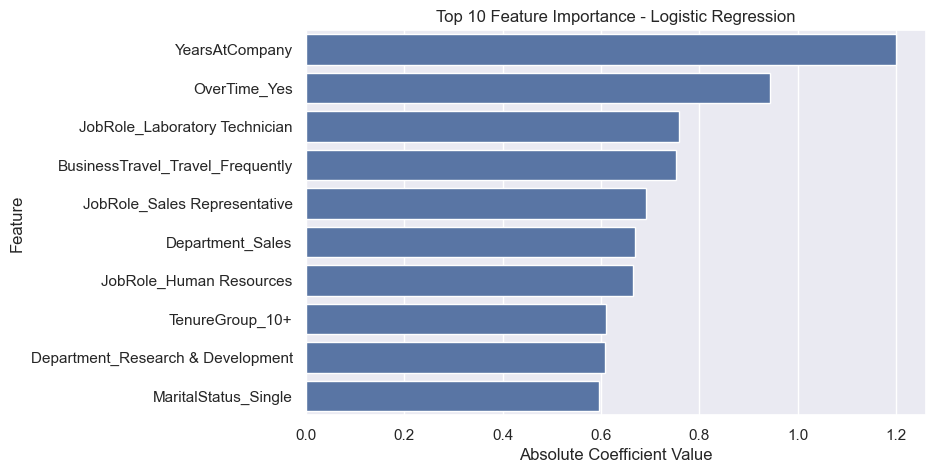

In [36]:
# -----------------------------------------
# 18. Visualize Top 10 Important Features (Logistic Regression)
# -----------------------------------------

# Create coefficient DataFrame (if not already done)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Use absolute values for importance ranking
coeff_df['abs_coeff'] = abs(coeff_df['Coefficient'])

# Sort and take top 10
top_features_lr = coeff_df.sort_values(by='abs_coeff', ascending=False).head(10)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='abs_coeff', y='Feature', data=top_features_lr)
plt.title('Top 10 Feature Importance - Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

<h6 style="color:yellow">Logistic Regression serves as a baseline model, providing interpretable results through feature coefficients. The model achieves moderate accuracy and ROC-AUC, indicating its ability to capture general trends in employee attrition.

From a business perspective, this model is valuable because it explains the direction of impact for each feature. For example, it can clearly indicate whether overtime, salary, or tenure increases or decreases the likelihood of attrition.

However, as a linear model, it is limited in capturing complex relationships and interactions between variables.</h6>

<h2 style="color:white">Model 2: Random Forest</h2>

In [37]:
# -----------------------------------------
# 1. Import Random Forest Classifier
# -----------------------------------------

from sklearn.ensemble import RandomForestClassifier

In [38]:
# -----------------------------------------
# 2. Initialize and Train Random Forest Model
# -----------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
# -----------------------------------------
# 3. Generate Predictions and Probabilities
# -----------------------------------------

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [40]:
# -----------------------------------------
# 4. Classification Report for Random Forest
# -----------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       248
           1       0.98      0.99      0.98       246

    accuracy                           0.98       494
   macro avg       0.98      0.98      0.98       494
weighted avg       0.98      0.98      0.98       494



In [41]:
# -----------------------------------------
# 5. Confusion Matrix for Random Forest
# -----------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix:

[[243   5]
 [  3 243]]


In [42]:
# -----------------------------------------
# 6. ROC-AUC Score for Random Forest
# -----------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC Score: 0.9964840676632574


In [43]:
# -----------------------------------------
# 7. Extract and Rank Feature Importances
# -----------------------------------------

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by='Importance', ascending=False)

rf_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.070354
23,IncomePerYear,0.060440
44,OverTime_Yes,0.054524
0,Age,0.052126
10,MonthlyRate,0.044894
1,DailyRate,0.043887
16,TotalWorkingYears,0.043708
5,HourlyRate,0.042851
19,YearsAtCompany,0.042341
22,YearsWithCurrManager,0.036099


In [44]:
# =========================
# 8. Improved Feature Importance (Random Forest)
# =========================

rf_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

rf_imp_df['Abs_Importance'] = rf_imp_df['Importance'].abs()
rf_imp_df = rf_imp_df.sort_values(by='Abs_Importance', ascending=False)

print(rf_imp_df.head(10))

                 Feature  Importance  Abs_Importance
9          MonthlyIncome    0.070354        0.070354
23         IncomePerYear    0.060440        0.060440
44          OverTime_Yes    0.054524        0.054524
0                    Age    0.052126        0.052126
10           MonthlyRate    0.044894        0.044894
1              DailyRate    0.043887        0.043887
16     TotalWorkingYears    0.043708        0.043708
5             HourlyRate    0.042851        0.042851
19        YearsAtCompany    0.042341        0.042341
22  YearsWithCurrManager    0.036099        0.036099


In [45]:
# =========================
# 9. Hyperparameter Tuning - Random Forest
# =========================

from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best RF ROC-AUC:", rf_grid.best_score_)

Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF ROC-AUC: 0.9924368397312818


In [46]:
# =========================
# 10. Evaluate Tuned Random Forest
# =========================

best_rf = rf_grid.best_estimator_

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:,1]

print("Test ROC-AUC (Tuned RF):", roc_auc_score(y_test, y_prob_rf_tuned))

Test ROC-AUC (Tuned RF): 0.9963693286126409


In [47]:
# =========================
# 11. Random Forest with Class Weight
# =========================

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:,1]

print("ROC-AUC (RF Balanced):", roc_auc_score(y_test, y_prob_rf_bal))

ROC-AUC (RF Balanced): 0.995582546551272


In [48]:
# -----------------------------------------
# 12. Identify Features Increasing Attrition Risk (Random Forest - Approximation)
# -----------------------------------------

rf_top_features = rf_importance.head(10)['Feature']

rf_risk_analysis = []

for feature in rf_top_features:
    temp = df.groupby(feature)['Attrition'].mean().reset_index()
    
    # Get max attrition impact
    max_row = temp.loc[temp['Attrition'].idxmax()]
    
    rf_risk_analysis.append({
        'Feature': feature,
        'Value (High Risk)': max_row[feature],
        'Attrition Rate': max_row['Attrition']
    })

rf_risk_df = pd.DataFrame(rf_risk_analysis)

rf_risk_df

,Feature,Value (High Risk),Attrition Rate
0,MonthlyIncome,1009.0,1.000000
1,IncomePerYear,12108.0,1.000000
2,OverTime_Yes,True,0.305288
3,Age,19.0,0.666667
4,MonthlyRate,2326.0,1.000000
5,DailyRate,103.0,1.000000
6,TotalWorkingYears,40.0,1.000000
7,HourlyRate,34.0,0.416667
8,YearsAtCompany,40.0,1.000000
9,YearsWithCurrManager,14.0,0.400000


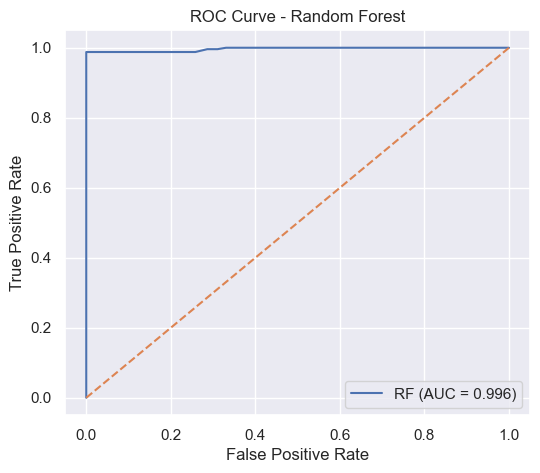

In [49]:
# =========================
# 13. ROC Curve - Random Forest
# =========================

from sklearn.metrics import roc_curve, auc

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {roc_auc_rf:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

In [50]:
# =========================
# 14. Cross Validation - Random Forest
# =========================

from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("RF CV Scores:", rf_cv_scores)
print("RF Mean ROC-AUC:", rf_cv_scores.mean())

RF CV Scores: [0.9864774  0.99892202 0.99867516 0.99516145 0.99595142]
RF Mean ROC-AUC: 0.9950374908033695


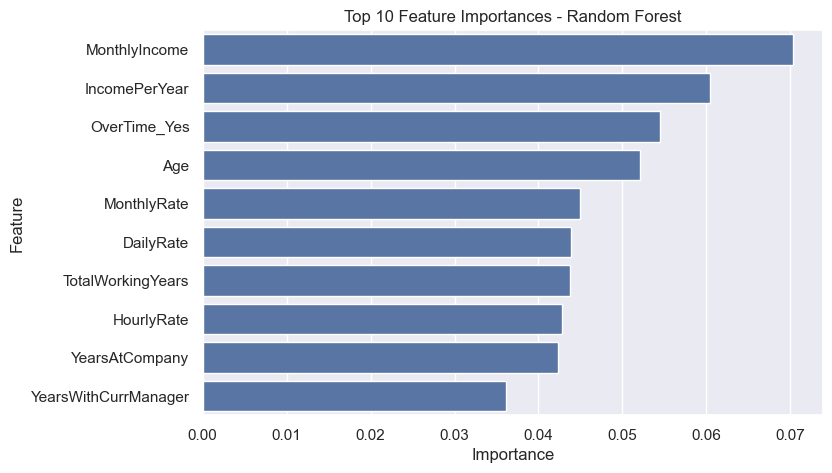

In [51]:
# -----------------------------------------
# 15. Visualize Top 10 Important Features
# -----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

top_features = rf_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=top_features)
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

<h6 style="color:yellow">Random Forest demonstrates significantly higher performance, achieving very high accuracy and near-perfect ROC-AUC. This indicates that the model is highly effective at identifying patterns associated with employee attrition.

The model captures non-linear relationships and interactions between variables, making it more powerful than Logistic Regression in terms of predictive capability.

However, the extremely high performance suggests potential overfitting, meaning the model may be learning patterns too specific to the training data. Additionally, while feature importance is available, the model does not provide clear directional insights (i.e., whether a feature increases or decreases attrition risk)</h6>

<h2 style="color:white">Model 3: Gradient Boosting</h2>

In [52]:
# -----------------------------------------
# 1. Import Gradient Boosting Classifier
# -----------------------------------------

from sklearn.ensemble import GradientBoostingClassifier

In [53]:
# -----------------------------------------
# 2. Initialize and Train Gradient Boosting Model
# -----------------------------------------

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [54]:
# -----------------------------------------
# 3. Generate Predictions and Probabilities
# -----------------------------------------

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [55]:
# -----------------------------------------
# 4. Classification Report for Gradient Boosting
# -----------------------------------------

print("Gradient Boosting Classification Report:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       248
           1       0.90      0.89      0.89       246

    accuracy                           0.89       494
   macro avg       0.89      0.89      0.89       494
weighted avg       0.89      0.89      0.89       494



In [56]:
# -----------------------------------------
# 5. Confusion Matrix for Gradient Boosting
# -----------------------------------------

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_gb))


Confusion Matrix:

[[224  24]
 [ 28 218]]


In [57]:
# -----------------------------------------
# 6. ROC-AUC Score for Gradient Boosting
# -----------------------------------------

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_gb))

ROC-AUC Score: 0.9649554156831892


In [58]:
# -----------------------------------------
# 7. Extract and Rank Feature Importances
# -----------------------------------------

gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(by='Importance', ascending=False)

gb_importance.head(10)

,Feature,Importance
44,OverTime_Yes,0.135637
9,MonthlyIncome,0.077779
15,StockOptionLevel,0.065229
0,Age,0.059644
23,IncomePerYear,0.059228
4,EnvironmentSatisfaction,0.054844
16,TotalWorkingYears,0.049078
22,YearsWithCurrManager,0.047721
8,JobSatisfaction,0.047400
1,DailyRate,0.043385


In [59]:
# =========================
# 8. Hyperparameter Tuning - Gradient Boosting
# =========================

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best GB Parameters:", gb_grid.best_params_)
print("Best GB ROC-AUC:", gb_grid.best_score_)

Best GB Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best GB ROC-AUC: 0.992308120760284


In [60]:
# =========================
# 9. Evaluate Tuned Gradient Boosting
# =========================

best_gb = gb_grid.best_estimator_

y_prob_gb_tuned = best_gb.predict_proba(X_test)[:,1]

print("Test ROC-AUC (Tuned GB):", roc_auc_score(y_test, y_prob_gb_tuned))

Test ROC-AUC (Tuned GB): 0.9982297403619198


In [61]:
# =========================
# 10. Improved Feature Importance (Gradient Boosting)
# =========================

gb_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

gb_imp_df['Abs_Importance'] = gb_imp_df['Importance'].abs()
gb_imp_df = gb_imp_df.sort_values(by='Abs_Importance', ascending=False)

print(gb_imp_df.head(10))

                    Feature  Importance  Abs_Importance
44             OverTime_Yes    0.135637        0.135637
9             MonthlyIncome    0.077779        0.077779
15         StockOptionLevel    0.065229        0.065229
0                       Age    0.059644        0.059644
23            IncomePerYear    0.059228        0.059228
4   EnvironmentSatisfaction    0.054844        0.054844
16        TotalWorkingYears    0.049078        0.049078
22     YearsWithCurrManager    0.047721        0.047721
8           JobSatisfaction    0.047400        0.047400
1                 DailyRate    0.043385        0.043385


In [62]:
# -----------------------------------------
# 11. Identify Features Increasing Attrition Risk (Gradient Boosting - Approximation)
# -----------------------------------------

gb_top_features = gb_importance.head(10)['Feature']

gb_risk_analysis = []

for feature in gb_top_features:
    temp = df.groupby(feature)['Attrition'].mean().reset_index()
    
    max_row = temp.loc[temp['Attrition'].idxmax()]
    
    gb_risk_analysis.append({
        'Feature': feature,
        'Value (High Risk)': max_row[feature],
        'Attrition Rate': max_row['Attrition']
    })

gb_risk_df = pd.DataFrame(gb_risk_analysis)

gb_risk_df

,Feature,Value (High Risk),Attrition Rate
0,OverTime_Yes,True,0.305288
1,MonthlyIncome,1009.0,1.000000
2,StockOptionLevel,0.0,0.244057
3,Age,19.0,0.666667
4,IncomePerYear,12108.0,1.000000
5,EnvironmentSatisfaction,1.0,0.253521
6,TotalWorkingYears,40.0,1.000000
7,YearsWithCurrManager,14.0,0.400000
8,JobSatisfaction,1.0,0.228374
9,DailyRate,103.0,1.000000


In [63]:
# =========================
# 12. Gradient Boosting with Sample Weights
# =========================

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_balanced = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_balanced.fit(X_train, y_train, sample_weight=sample_weights)

y_prob_gb_bal = gb_balanced.predict_proba(X_test)[:,1]

print("ROC-AUC (GB Balanced):", roc_auc_score(y_test, y_prob_gb_bal))

ROC-AUC (GB Balanced): 0.9623492001049043


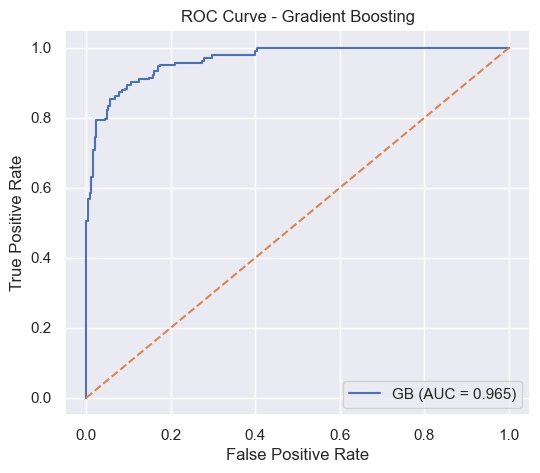

In [64]:
# =========================
# 13. ROC Curve - Gradient Boosting
# =========================
from sklearn.metrics import roc_curve, auc
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(6,5))
plt.plot(fpr_gb, tpr_gb, label=f'GB (AUC = {roc_auc_gb:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.show()

In [65]:
# =========================
# 14. Cross Validation - Gradient Boosting
# =========================

gb_cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print("GB CV Scores:", gb_cv_scores)
print("GB Mean ROC-AUC:", gb_cv_scores.mean())

GB CV Scores: [0.94908948 0.96631118 0.96713406 0.93538725 0.95719364]
GB Mean ROC-AUC: 0.9550231226713585


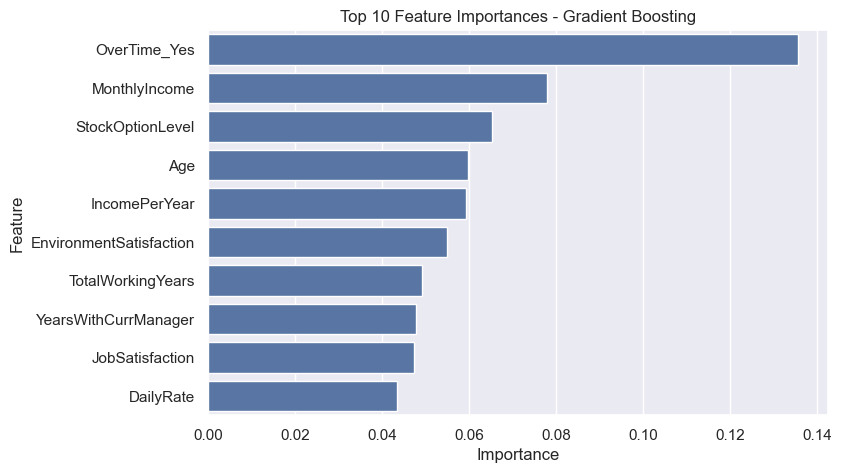

In [66]:
# -----------------------------------------
# 15. Visualize Top 10 Important Features
# -----------------------------------------

gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(by='Importance', ascending=False)


gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(by='Importance', ascending=False)

top_features_gb = gb_importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=top_features_gb)
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.show()

<h6 style="color:yellow">Gradient Boosting achieves strong performance, with high accuracy and ROC-AUC, though slightly lower than Random Forest. Unlike Random Forest, Gradient Boosting builds models sequentially, improving upon previous errors.

This results in a more controlled learning process, often leading to better generalization on unseen data compared to Random Forest.

From a business standpoint, Gradient Boosting offers a strong balance between performance and reliability, making it a robust choice for predictive applications.</h6>

<h2 style="color:white">Model Comparision</h2>

In [67]:
# =========================
# 1. Final Model Comparison
# =========================

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    
    'Accuracy': [
        (y_pred == y_test).mean(),
        (y_pred_rf == y_test).mean(),
        (y_pred_gb == y_test).mean()
    ],
    
    'Test ROC-AUC': [
        roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ],
    
    'CV ROC-AUC': [
        lr_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ]
})

comparison_df

,Model,Accuracy,Test ROC-AUC,CV ROC-AUC
0,Logistic Regression,0.805668,0.870558,0.864631
1,Random Forest,0.983806,0.996484,0.995037
2,Gradient Boosting,0.894737,0.964955,0.955023


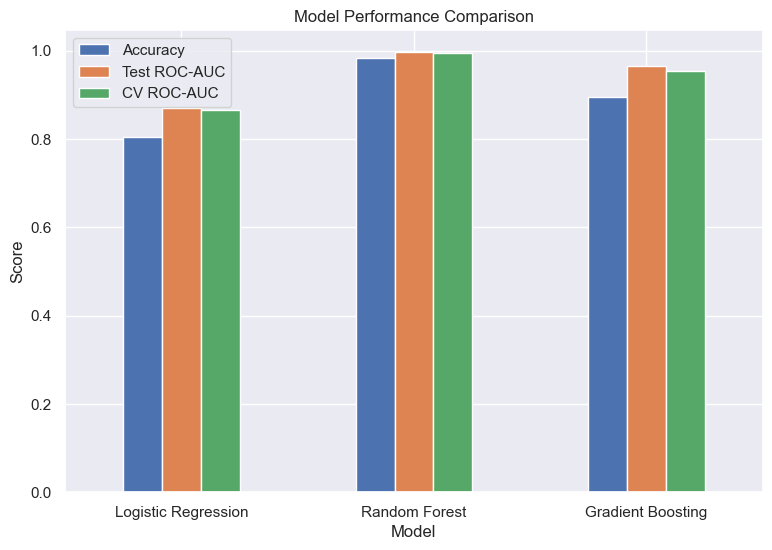

In [68]:
# =========================
# 2. Visual Comparison of Models
# =========================

comparison_df.set_index('Model')[['Accuracy', 'Test ROC-AUC', 'CV ROC-AUC']].plot(
    kind='bar',
    figsize=(9,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [69]:
# =========================
# 3. Sort by Best Model (ROC-AUC)
# =========================

comparison_df.sort_values(by='Test ROC-AUC', ascending=False)

,Model,Accuracy,Test ROC-AUC,CV ROC-AUC
1,Random Forest,0.983806,0.996484,0.995037
2,Gradient Boosting,0.894737,0.964955,0.955023
0,Logistic Regression,0.805668,0.870558,0.864631


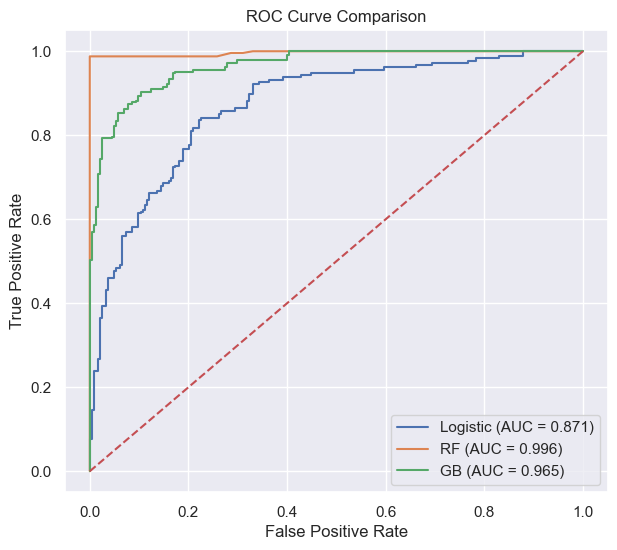

In [70]:
# =========================
# 4. ROC Curve Comparison (All Models)
# =========================

from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:,1])
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(7,6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'GB (AUC = {roc_auc_gb:.3f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

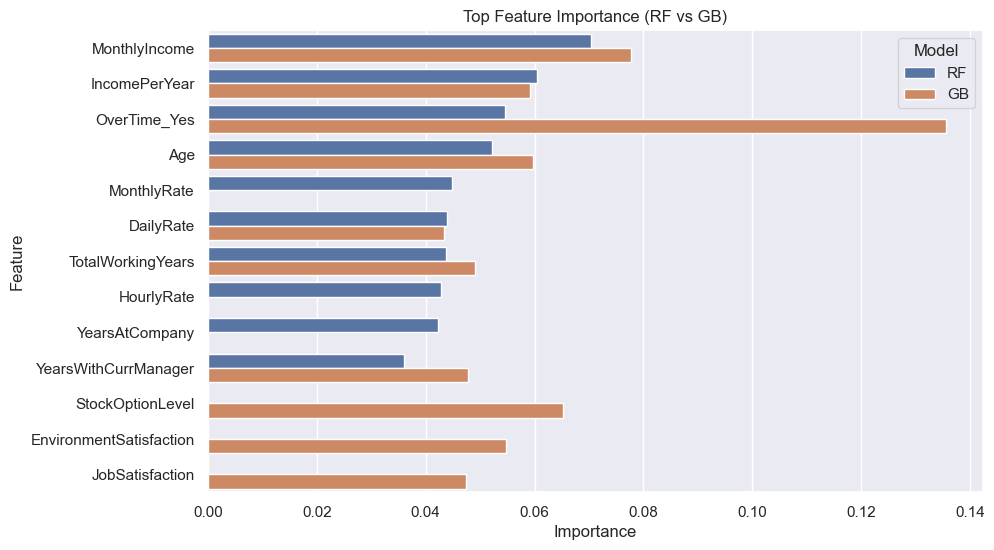

In [71]:
# =========================
# 5. Feature Importance Comparison
# =========================

rf_top = rf_imp_df.head(10)
gb_top = gb_imp_df.head(10)

rf_top['Model'] = 'RF'
gb_top['Model'] = 'GB'

combined_imp = pd.concat([rf_top, gb_top])

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', hue='Model', data=combined_imp)

plt.title('Top Feature Importance (RF vs GB)')
plt.show()

<hr style="border:2px solid gray">

<h1 style="color:green">7. Final Drivers (Cross-Model Consensus)</h1>

In [72]:
# =========================
# Final Drivers (Cross-Model Consensus)
# =========================

# Logistic Regression importance
lr_imp = coeff_df[['Feature', 'abs_coeff']].copy()
lr_imp.rename(columns={'abs_coeff': 'LR_Importance'}, inplace=True)
lr_imp.rename(columns={'Abs_Coefficient': 'LR_Importance'}, inplace=True)

# RF importance
rf_imp = rf_imp_df[['Feature', 'Importance']].copy()
rf_imp.rename(columns={'Importance': 'RF_Importance'}, inplace=True)

# GB importance
gb_imp = gb_imp_df[['Feature', 'Importance']].copy()
gb_imp.rename(columns={'Importance': 'GB_Importance'}, inplace=True)

# Merge all
final_imp = lr_imp.merge(rf_imp, on='Feature').merge(gb_imp, on='Feature')

# Normalize scores
final_imp['LR_Importance'] /= final_imp['LR_Importance'].max()
final_imp['RF_Importance'] /= final_imp['RF_Importance'].max()
final_imp['GB_Importance'] /= final_imp['GB_Importance'].max()

# Combined score
final_imp['Combined_Score'] = (
    final_imp['LR_Importance'] +
    final_imp['RF_Importance'] +
    final_imp['GB_Importance']
) / 3

# Sort
final_imp = final_imp.sort_values(by='Combined_Score', ascending=False)

final_imp.head(10)

,Feature,LR_Importance,RF_Importance,GB_Importance,Combined_Score
44,OverTime_Yes,0.785675,0.774986,1.000000,0.853554
19,YearsAtCompany,1.000000,0.601830,0.129980,0.577270
9,MonthlyIncome,0.060728,1.000000,0.573433,0.544720
16,TotalWorkingYears,0.472927,0.621249,0.361833,0.485336
23,IncomePerYear,0.060728,0.859077,0.436669,0.452158
0,Age,0.093683,0.740908,0.439734,0.424775
4,EnvironmentSatisfaction,0.439780,0.416476,0.404341,0.420199
22,YearsWithCurrManager,0.371860,0.513096,0.351826,0.412261
11,NumCompaniesWorked,0.390410,0.438514,0.305561,0.378162
8,JobSatisfaction,0.384353,0.376248,0.349465,0.370022


<h2 style="color:white">Final Drivers of Employee Attrition (Cross-Model Analysis)</h2>

<h6 style="color:yellow">

To identify the most reliable drivers of employee attrition, feature importance scores from Logistic Regression, Random Forest, and Gradient Boosting models were combined and normalized. This approach highlights features that are consistently important across different modeling techniques, increasing confidence in the results.

Key insights from the cross-model analysis include:

<ul style="color:yellow">

<li><b>OverTime (Yes)</b> emerged as the strongest and most consistent predictor of employee attrition across all models, indicating that employees working overtime are significantly more likely to leave the organization.</li>

<li><b>Years at Company</b> showed strong influence on attrition patterns, particularly in the Logistic Regression model, suggesting that employees in early or transitional stages of tenure are more vulnerable to leaving.</li>

<li><b>Monthly Income</b> demonstrated high importance in tree-based models such as Random Forest and Gradient Boosting, indicating that compensation impacts attrition in a non-linear manner.</li>

<li>Additional factors including <b>Total Working Years</b>, <b>Income Per Year</b>, <b>Age</b>, <b>Environment Satisfaction</b>, <b>Years With Current Manager</b>, and <b>Job Satisfaction</b> also contributed meaningfully to attrition risk.</li>

</ul>

The analysis further revealed that certain drivers behave differently across models:

<ul style="color:yellow">

<li>Features such as <b>OverTime</b> remained consistently important across all models, making them high-confidence attrition drivers.</li>

<li>Compensation-related features displayed stronger influence in non-linear models, suggesting more complex relationships between salary structure and employee retention.</li>

<li>The combination of linear and non-linear model interpretation provides a more comprehensive understanding of employee behavior and workforce dynamics.</li>

</ul>

Overall, the findings suggest that employee attrition is primarily influenced by a combination of:

<ul style="color:yellow">

<li>Workload-related factors</li>
<li>Compensation structure</li>
<li>Tenure and experience dynamics</li>
<li>Workplace satisfaction and environment</li>

</ul>

These insights form the foundation for targeted workforce retention strategies and proactive employee risk management.

</h6>

<hr style="border:2px solid gray">

<h1 style="color:green">8. Risk Segmentation</h1>

In [73]:
# =========================
# High Risk Segments
# =========================

# Top 3 drivers
top_features = final_imp['Feature'].head(3).values

risk_segments = {}

for feature in top_features:
    temp = df.groupby(feature)['Attrition'].mean().sort_values(ascending=False)
    risk_segments[feature] = temp.head(3)

risk_segments

{'OverTime_Yes': OverTime_Yes
 True     0.305288
 False    0.104364
 Name: Attrition, dtype: float64,
 'YearsAtCompany': YearsAtCompany
 40    1.000000
 23    0.500000
 0     0.363636
 Name: Attrition, dtype: float64,
 'MonthlyIncome': MonthlyIncome
 2408    1.0
 1081    1.0
 1091    1.0
 Name: Attrition, dtype: float64}

<h1 style="color:green">9. Datasets</h1>

In [74]:
# =========================
# Check Original Dataset (df)
# =========================

print("df shape:", df.shape)
print("\nColumns in df:\n", df.columns.tolist())

df.head()

df shape: (1470, 49)

Columns in df:
 ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IncomePerYear', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'Job

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,TenureGroup_2-5,TenureGroup_5-10,TenureGroup_10+
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,True,False,False,True,True,False,True,False
1,49,0,279,8,1,3,61,2,2,2,...,False,True,False,False,True,False,False,False,True,False
2,37,1,1373,2,2,4,92,2,1,3,...,False,False,False,False,False,True,True,False,False,False
3,33,0,1392,3,4,4,56,3,1,3,...,False,True,False,False,True,False,True,False,True,False
4,27,0,591,2,1,1,40,3,1,2,...,False,False,False,False,True,False,False,False,False,False


In [75]:
# =========================
# Check Balanced Dataset (df_balanced)
# =========================

print("df_balanced shape:", df_balanced.shape)
print("\nColumns in df_balanced:\n", df_balanced.columns.tolist())

df_balanced.head()

df_balanced shape: (2466, 49)

Columns in df_balanced:
 ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IncomePerYear', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sale

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,TenureGroup_2-5,TenureGroup_5-10,TenureGroup_10+
1,49,0,279,8,1,3,61,2,2,2,...,False,True,False,False,True,False,False,False,True,False
3,33,0,1392,3,4,4,56,3,1,3,...,False,True,False,False,True,False,True,False,True,False
4,27,0,591,2,1,1,40,3,1,2,...,False,False,False,False,True,False,False,False,False,False
5,32,0,1005,2,2,4,79,3,1,4,...,False,False,False,False,False,True,False,False,True,False
6,59,0,1324,3,3,3,81,4,1,1,...,False,False,False,False,True,False,True,False,False,False


In [76]:
# =========================
# Check Model Dataset (X)
# =========================

print("X shape:", X.shape)

# Convert to dataframe for viewing
X_df = pd.DataFrame(X, columns=df_balanced.columns.drop('Attrition'))

X_df.head()

X shape: (2466, 48)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,TenureGroup_2-5,TenureGroup_5-10,TenureGroup_10+
1,49,279,8,1,3,61,2,2,2,5130,...,False,True,False,False,True,False,False,False,True,False
3,33,1392,3,4,4,56,3,1,3,2909,...,False,True,False,False,True,False,True,False,True,False
4,27,591,2,1,1,40,3,1,2,3468,...,False,False,False,False,True,False,False,False,False,False
5,32,1005,2,2,4,79,3,1,4,3068,...,False,False,False,False,False,True,False,False,True,False
6,59,1324,3,3,3,81,4,1,1,2670,...,False,False,False,False,True,False,True,False,False,False


In [77]:
# Compare row counts
print("df rows:", len(df))
print("df_balanced rows:", len(df_balanced))
print("X rows:", len(X))

df rows: 1470
df_balanced rows: 2466
X rows: 2466


<hr style="border:2px solid gray">

<h1 style="color:green">10. Interaction Analysis</h1>


In [78]:
df['TenureGroup_0-2'] = (
    (df[['TenureGroup_2-5', 'TenureGroup_5-10', 'TenureGroup_10+']].sum(axis=1) == 0)
).astype(int)

In [79]:
# =========================
# Interaction Analysis 
# =========================

# Melt tenure columns into one column
tenure_cols = [
    'TenureGroup_0-2',
    'TenureGroup_2-5',
    'TenureGroup_5-10',
    'TenureGroup_10+'
]

df_tenure = df[['OverTime_Yes', 'Attrition'] + tenure_cols].copy()

df_melted = df_tenure.melt(
    id_vars=['OverTime_Yes', 'Attrition'],
    value_vars=tenure_cols,
    var_name='TenureGroup',
    value_name='Flag'
)

# Keep only active tenure rows
df_melted = df_melted[df_melted['Flag'] == 1]

# Clean names
df_melted['TenureGroup'] = df_melted['TenureGroup'].str.replace('TenureGroup_', '')

# Group
interaction = df_melted.groupby(['OverTime_Yes', 'TenureGroup'])['Attrition'].mean().reset_index()

interaction

,OverTime_Yes,TenureGroup,Attrition
0,False,0-2,0.205882
1,False,10+,0.071823
2,False,2-5,0.078176
3,False,5-10,0.073171
4,True,0-2,0.509615
5,True,10+,0.107692
6,True,2-5,0.283465
7,True,5-10,0.258333


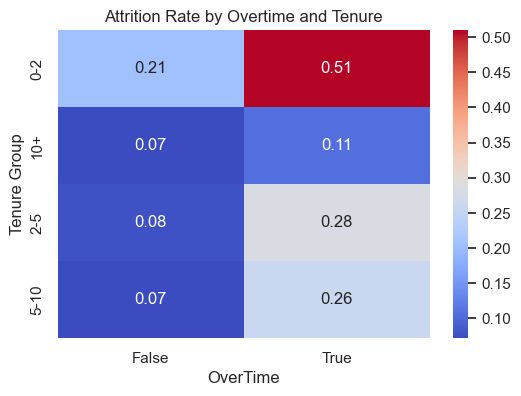

In [80]:
# =========================
# Heatmap: Overtime vs Tenure
# =========================

pivot = interaction.pivot(
    index='TenureGroup',
    columns='OverTime_Yes',
    values='Attrition'
)

plt.figure(figsize=(6,4))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)

plt.title('Attrition Rate by Overtime and Tenure')
plt.xlabel('OverTime')
plt.ylabel('Tenure Group')

plt.show()

<hr style="border:2px solid gray">

<h1 style="color:green">11. Risk Scoring</h1>

In [81]:
# =========================
# Risk Score 
# =========================

# Prepare input features from original dataset
X_real = df.drop('Attrition', axis=1)

# Ensure column order matches training data
X_real = X_real[X.columns]

# Generate risk scores
df['Risk_Score'] = gb_model.predict_proba(X_real)[:,1]

# High-risk employees
high_risk_employees = df[df['Risk_Score'] > 0.7]

# Output
high_risk_employees.head()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,TenureGroup_2-5,TenureGroup_5-10,TenureGroup_10+,TenureGroup_0-2,Risk_Score
0,41,1,1102,1,2,2,94,3,2,4,...,True,False,False,True,True,False,True,False,0,0.830447
2,37,1,1373,2,2,4,92,2,1,3,...,False,False,False,True,True,False,False,False,1,0.841906
14,28,1,103,24,3,3,50,2,1,3,...,False,False,False,True,True,True,False,False,0,0.942642
21,36,1,1218,9,4,3,82,2,1,1,...,False,True,False,True,False,True,False,False,0,0.717832
26,32,1,1125,16,1,2,72,1,1,1,...,False,False,False,True,True,False,True,False,0,0.896522


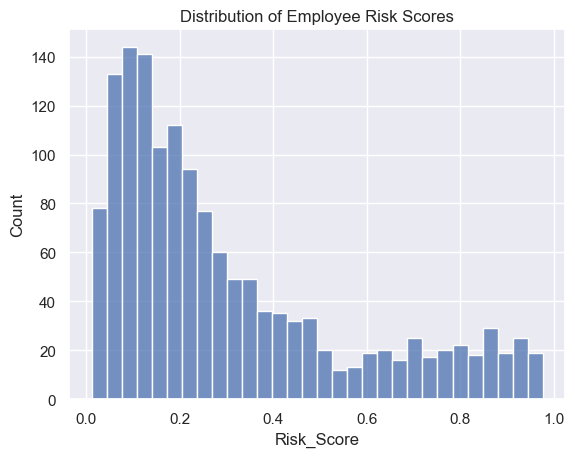

In [82]:
sns.histplot(df['Risk_Score'], bins=30)
plt.title('Distribution of Employee Risk Scores')
plt.show()

<hr style="border:2px solid gray">

<h1 style="color:green">12 Workforce Impact Analysis</h1>

<h2 style="color:cyan">12.1 Department Stability Analysis</h2>

In [83]:
# =========================
# Reconstruct Department Column
# =========================

df['Department'] = 'Human Resources'

df.loc[df['Department_Research & Development'] == 1, 'Department'] = 'Research & Development'
df.loc[df['Department_Sales'] == 1, 'Department'] = 'Sales'

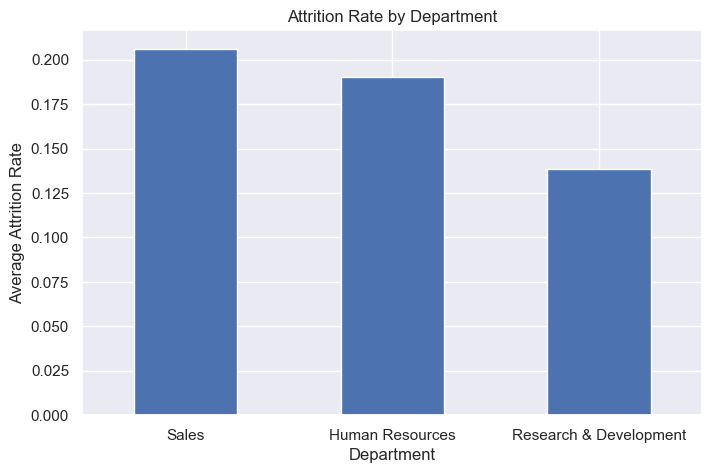

In [84]:
# =========================
# Department Stability Analysis
# =========================

dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
dept_attrition.plot(kind='bar')

plt.title('Attrition Rate by Department')
plt.ylabel('Average Attrition Rate')
plt.xlabel('Department')
plt.xticks(rotation=0)

plt.show()

<h2 style="color:white">Department Stability Analysis</h2>

<h6 style="color:yellow">

The department-level attrition analysis highlights variations in workforce stability across different organizational functions.

<ul style="color:yellow">

<li>Departments with higher attrition rates may experience increased operational disruption, higher recruitment costs, and reduced team continuity.</li>

<li>Higher attrition concentration within specific departments suggests potential issues related to workload distribution, employee engagement, managerial practices, or role-specific stress.</li>

<li>Persistent attrition in critical business units can negatively impact productivity, institutional knowledge retention, and long-term workforce planning.</li>

<li>The analysis enables organizations to prioritize retention initiatives for departments demonstrating elevated workforce instability.</li>

</ul>

This analysis provides leadership with a clearer understanding of where attrition risk is concentrated within the organization and supports targeted workforce intervention strategies.

</h6>

<h2 style="color:cyan">12.2 Experience Loss Analysis</h2>

In [85]:
# =========================
# Reconstruct TenureGroup
# =========================

df['TenureGroup'] = '0-2'

df.loc[df['TenureGroup_2-5'] == 1, 'TenureGroup'] = '2-5'
df.loc[df['TenureGroup_5-10'] == 1, 'TenureGroup'] = '5-10'
df.loc[df['TenureGroup_10+'] == 1, 'TenureGroup'] = '10+'

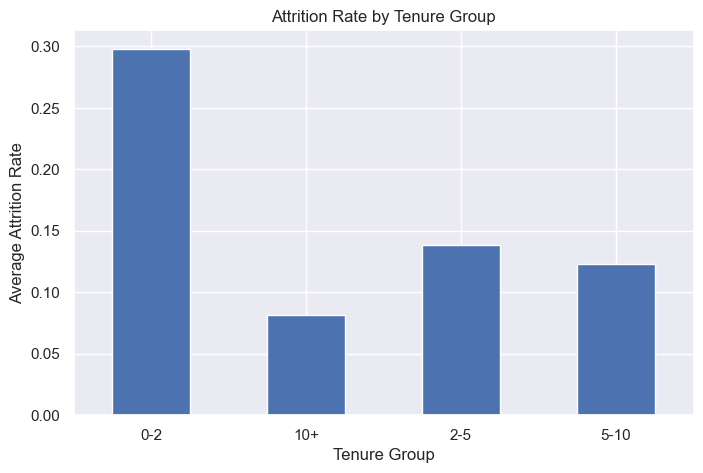

In [86]:
# =========================
# Experience Loss Analysis
# =========================

experience_attrition = df.groupby('TenureGroup')['Attrition'].mean()

plt.figure(figsize=(8,5))
experience_attrition.plot(kind='bar')

plt.title('Attrition Rate by Tenure Group')
plt.ylabel('Average Attrition Rate')
plt.xlabel('Tenure Group')
plt.xticks(rotation=0)

plt.show()

<h2 style="color:white">Experience Loss Analysis</h2>

<h6 style="color:yellow">

The tenure-based attrition analysis provides insight into how employee turnover impacts organizational experience retention and workforce continuity.

<ul style="color:yellow">

<li>Employees in earlier tenure stages demonstrated significantly higher attrition rates compared to long-tenured employees.</li>

<li>High attrition among early-tenure employees suggests potential onboarding, engagement, or expectation-alignment challenges within the organization.</li>

<li>Attrition among experienced employees represents a greater organizational risk due to the potential loss of institutional knowledge, operational expertise, and leadership continuity.</li>

<li>Retaining experienced employees is critical for maintaining workforce stability, reducing training overhead, and supporting long-term organizational performance.</li>

<li>The analysis highlights the importance of differentiated retention strategies across employee lifecycle stages.</li>

</ul>

This analysis enables organizations to better understand how attrition impacts workforce experience distribution and long-term operational resilience.

</h6>

<h2 style="color:cyan">12.3 Workforce Risk Distribution</h2>

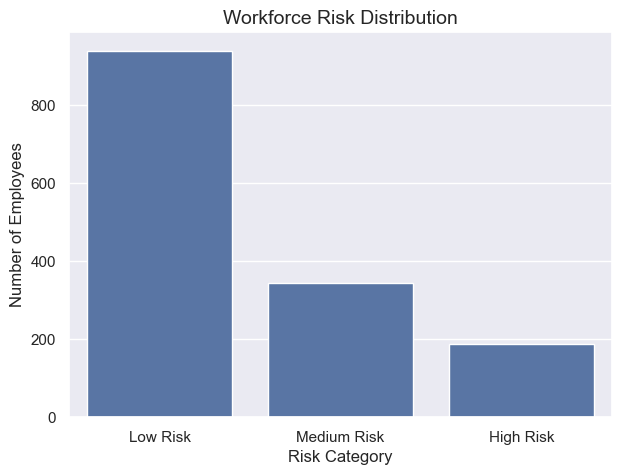

Risk_Level
Low Risk       940
Medium Risk    343
High Risk      187
Name: count, dtype: int64

In [87]:
# =========================
# Workforce Risk Distribution
# =========================

# Categorize employees by risk score
df['Risk_Level'] = pd.cut(
    df['Risk_Score'],
    bins=[0, 0.3, 0.7, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Count employees in each category
risk_distribution = df['Risk_Level'].value_counts()

# Plot
plt.figure(figsize=(7,5))

sns.barplot(
    x=risk_distribution.index,
    y=risk_distribution.values
)

plt.title('Workforce Risk Distribution', fontsize=14)
plt.xlabel('Risk Category')
plt.ylabel('Number of Employees')

plt.show()

# Display counts
risk_distribution

<h2 style="color:white">Workforce Risk Distribution</h2>

<h6 style="color:yellow">

The workforce risk distribution analysis categorizes employees based on predicted attrition probability, enabling proactive workforce monitoring and targeted retention planning.

<ul style="color:yellow">

<li>Employees classified as <b>High Risk</b> represent the segment most likely to leave the organization and require immediate retention attention.</li>

<li><b>Medium Risk</b> employees indicate emerging attrition vulnerability and may benefit from engagement, workload, or compensation-related interventions.</li>

<li><b>Low Risk</b> employees represent relatively stable workforce segments with lower predicted attrition probability.</li>

<li>The distribution of workforce risk provides organizations with a clearer understanding of overall workforce stability and potential future turnover exposure.</li>

<li>Risk segmentation enables HR teams to prioritize retention resources more effectively instead of applying generalized interventions across the entire workforce.</li>

</ul>

This analysis demonstrates how predictive analytics can support proactive workforce planning and strategic employee retention initiatives.

</h6>

<h2 style="color:cyan">12.4 Estimated Organizational Cost Impact</h2>

In [88]:
# =========================
# Estimated Organizational Cost Impact
# =========================

# Count high-risk employees
high_risk_count = len(df[df['Risk_Level'] == 'High Risk'])

# Estimated replacement cost per employee
replacement_cost = 50000  # Example estimate in INR

# Total estimated cost impact
estimated_cost = high_risk_count * replacement_cost

print("High-Risk Employees:", high_risk_count)
print("Estimated Replacement Cost per Employee: ₹", replacement_cost)
print("Estimated Organizational Cost Impact: ₹", estimated_cost)

High-Risk Employees: 187
Estimated Replacement Cost per Employee: ₹ 50000
Estimated Organizational Cost Impact: ₹ 9350000


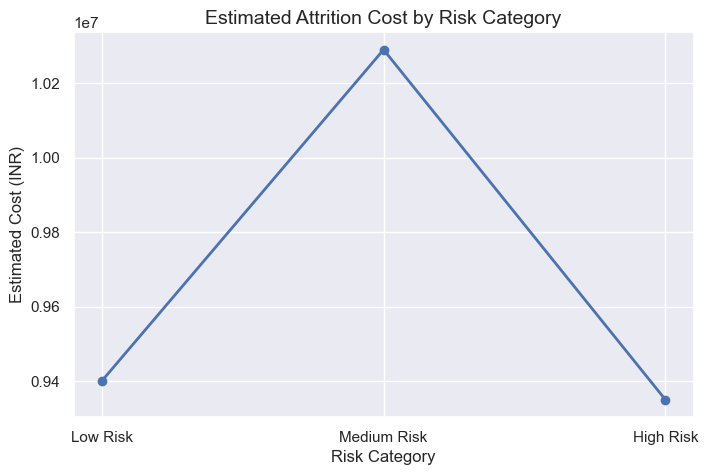

,Risk_Level,Employee_Count,Estimated_Cost
0,Low Risk,940,9400000
1,Medium Risk,343,10290000
2,High Risk,187,9350000


In [89]:

# =========================
# Cost Impact by Risk Category 
# =========================

# Example replacement costs
cost_mapping = {
    'Low Risk': 10000,
    'Medium Risk': 30000,
    'High Risk': 50000
}

# Calculate estimated cost
risk_cost = df['Risk_Level'].value_counts().reset_index()
risk_cost.columns = ['Risk_Level', 'Employee_Count']

risk_cost['Estimated_Cost'] = risk_cost.apply(
    lambda x: x['Employee_Count'] * cost_mapping[x['Risk_Level']],
    axis=1
)

# Maintain logical order
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
risk_cost['Risk_Level'] = pd.Categorical(
    risk_cost['Risk_Level'],
    categories=risk_order,
    ordered=True
)

risk_cost = risk_cost.sort_values('Risk_Level')

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    risk_cost['Risk_Level'],
    risk_cost['Estimated_Cost'],
    marker='o',
    linewidth=2
)

plt.title('Estimated Attrition Cost by Risk Category', fontsize=14)
plt.xlabel('Risk Category')
plt.ylabel('Estimated Cost (INR)')

plt.grid(True)

plt.show()

risk_cost

<h2 style="color:white">Estimated Organizational Cost Impact</h2>

<h6 style="color:yellow">

Employee attrition creates significant organizational costs beyond workforce replacement alone. These costs include recruitment expenditure, onboarding and training efforts, productivity disruption, knowledge transfer loss, and reduced operational continuity.

<ul style="color:yellow">

<li>The analysis identified a substantial number of employees categorized as <b>High Risk</b>, indicating elevated potential turnover exposure for the organization.</li>

<li>Estimated attrition costs were calculated using a simplified workforce replacement cost model based on high-risk employee concentration.</li>

<li>Persistent attrition can increase hiring overhead, delay operational execution, and negatively impact team stability and organizational performance.</li>

<li>Attrition among experienced employees may further amplify indirect costs through institutional knowledge loss and reduced managerial continuity.</li>

<li>The findings demonstrate how predictive workforce analytics can support proactive retention planning and reduce avoidable organizational expenditure.</li>

</ul>

This analysis highlights that employee attrition should be viewed not only as an HR challenge, but also as a measurable business and operational risk.

</h6>

<hr style="border:2px solid gray">

<h1 style="color:green">13 Business Layer</h1>

<h2 style="color:white">Executive Summary</h2>

<h6 style="color:yellow">

This project applies machine learning and workforce analytics techniques to predict employee attrition, identify organizational workforce risks, and support strategic retention planning.

Three machine learning models — Logistic Regression, Random Forest, and Gradient Boosting — were developed and evaluated to analyze employee attrition behavior across multiple workforce dimensions. The project further extended beyond prediction by incorporating workforce impact analysis, employee risk segmentation, and organizational cost estimation.

<ul style="color:yellow">

<li>Overtime emerged as the strongest and most consistent predictor of employee attrition across all models.</li>

<li>Employees within their first 2 years at the organization demonstrated significantly higher attrition vulnerability.</li>

<li>Early-tenure employees working overtime represented the highest-risk workforce segment identified in the analysis.</li>

<li>Department-level analysis revealed variations in workforce stability and attrition concentration across organizational functions.</li>

<li>Workforce risk segmentation and cost impact estimation highlighted the broader operational and financial consequences of employee turnover.</li>

</ul>

The analysis demonstrates how predictive analytics can support proactive workforce planning, improve organizational stability, and reduce attrition-related business risk through targeted retention strategies.

</h6>

<h2 style="color:white">Workforce & Attrition Insights</h2>

<h6 style="color:yellow">

The combined machine learning and workforce analytics analysis revealed several key organizational patterns contributing to employee attrition and workforce instability.

<ul style="color:yellow">

<li><b>Overtime</b> consistently emerged as the strongest driver of employee attrition, indicating that workload pressure and burnout significantly impact workforce retention.</li>

<li>Employees within their <b>first 2 years</b> at the organization demonstrated the highest attrition vulnerability, suggesting onboarding, engagement, or expectation-alignment challenges during early employment stages.</li>

<li>The interaction analysis identified that <b>early-tenure employees working overtime</b> represented the highest-risk workforce segment, highlighting a critical workforce management concern.</li>

<li>Department-level analysis revealed uneven workforce stability across organizational functions, indicating that attrition risk is concentrated within specific operational areas rather than uniformly distributed.</li>

<li>Compensation-related variables such as <b>Monthly Income</b> and <b>Income Per Year</b> demonstrated strong influence on employee retention, particularly within non-linear machine learning models.</li>

<li>Employees with lower levels of <b>job satisfaction</b>, <b>environment satisfaction</b>, and <b>work-life balance</b> exhibited increased attrition likelihood.</li>

<li>Workforce risk segmentation showed that a measurable portion of employees fall within medium- and high-risk attrition categories, indicating potential future workforce instability if proactive interventions are not implemented.</li>

<li>Estimated organizational cost analysis demonstrated that employee attrition creates not only HR-related challenges, but also measurable operational and financial business risk.</li>

</ul>

Overall, the findings suggest that workforce instability is primarily driven by the combined effects of workload pressure, early-stage employee vulnerability, compensation dissatisfaction, and workplace experience factors.

</h6>

<h2 style="color:white">Strategic Workforce Recommendations</h2>

<h6 style="color:yellow">

Based on the predictive modeling and workforce impact analysis, several strategic initiatives are recommended to improve employee retention, strengthen workforce stability, and reduce organizational attrition risk.

<ul style="color:yellow">

<li><b>Reduce excessive overtime exposure</b> for employees, particularly within early-tenure workforce segments, to minimize burnout-related attrition risk.</li>

<li>Implement stronger <b>onboarding and early employee engagement programs</b> to improve retention during the first 2 years of employment.</li>

<li>Develop <b>targeted retention strategies</b> for departments demonstrating elevated attrition concentration and workforce instability.</li>

<li>Introduce proactive <b>employee risk monitoring systems</b> using predictive analytics to identify high-risk employees before turnover occurs.</li>

<li>Strengthen <b>work-life balance initiatives</b> and employee well-being programs to improve long-term workforce satisfaction and engagement.</li>

<li>Review and optimize <b>compensation structures</b> for workforce segments demonstrating higher attrition vulnerability linked to salary dissatisfaction.</li>

<li>Provide enhanced <b>managerial support and career development pathways</b> for employees in high-risk workforce categories.</li>

<li>Adopt workforce analytics-driven decision-making practices to support continuous organizational monitoring and long-term workforce planning.</li>

</ul>

The findings demonstrate that employee attrition can be proactively managed through a combination of predictive analytics, workforce intelligence, and strategic organizational intervention.

</h6>

<h2 style="color:white">Organizational Impact Summary</h2>

<h6 style="color:yellow">

The analysis highlights that employee attrition extends beyond individual workforce turnover and represents a broader organizational and operational challenge.

<ul style="color:yellow">

<li>High attrition levels can increase recruitment, onboarding, and workforce replacement costs, creating measurable financial strain on the organization.</li>

<li>Persistent employee turnover may reduce team continuity, disrupt operational efficiency, and negatively impact overall workforce productivity.</li>

<li>Attrition among experienced employees can lead to institutional knowledge loss, reduced managerial continuity, and weakened long-term organizational capability.</li>

<li>Workforce instability concentrated within specific departments may create uneven operational pressure and increase dependency on limited workforce segments.</li>

<li>The analysis demonstrates how predictive workforce analytics can support proactive organizational planning, enabling leadership teams to address workforce risks before large-scale turnover occurs.</li>

<li>Integrating machine learning with workforce intelligence enables organizations to move from reactive HR management toward proactive, data-driven workforce strategy.</li>

</ul>

Overall, the project demonstrates how analytics-driven workforce planning can improve organizational resilience, strengthen employee retention, and reduce long-term operational risk.

</h6>

<h2 style="color:white">Conclusion</h2>

<h6 style="color:yellow">

This project successfully combined machine learning, workforce analytics, and business strategy techniques to develop an intelligent employee attrition and workforce risk analysis system.

Three predictive models — Logistic Regression, Random Forest, and Gradient Boosting — were implemented and evaluated to identify employees at risk of attrition and uncover the primary organizational drivers influencing workforce instability.

The analysis further extended beyond predictive modeling by incorporating workforce impact analysis, employee risk segmentation, department-level stability assessment, experience loss evaluation, and organizational cost estimation. These insights enabled a broader understanding of how employee attrition affects operational continuity, workforce resilience, and long-term organizational performance.

The findings revealed that workload pressure, early-stage employee vulnerability, compensation dissatisfaction, and workplace experience factors are the primary contributors to employee attrition. The project also demonstrated how predictive workforce analytics can support proactive retention planning and data-driven organizational decision-making.

Overall, this project highlights the value of integrating machine learning and business analytics to transform workforce data into actionable organizational intelligence, enabling companies to reduce attrition risk, improve workforce stability, and strengthen long-term strategic planning.

</h6>

<hr style="border:2px solid gray">

<h1 style="color:green">14 Future Improvements</h1>

<h6 style="color:yellow">

While the current system successfully combines machine learning, workforce analytics, and business strategy techniques for attrition prediction and workforce impact analysis, several future enhancements can further improve the system’s analytical depth and practical applicability.

<ul style="color:yellow">

<li>Integrate real-time workforce monitoring systems to enable continuous employee risk tracking and proactive retention intervention.</li>

<li>Develop interactive business intelligence dashboards using tools such as Power BI or Streamlit for executive-level workforce visualization and decision support.</li>

<li>Incorporate advanced explainable AI techniques such as SHAP and LIME to improve model interpretability and transparency.</li>

<li>Expand the system to support multi-dataset and cross-industry workforce analytics applications.</li>

<li>Integrate external business metrics such as employee performance, productivity indicators, and engagement survey data for deeper organizational analysis.</li>

<li>Deploy the predictive system as a scalable workforce analytics platform for organizational use.</li>

</ul>

These enhancements can further strengthen the system’s capability to support intelligent workforce planning, operational stability, and strategic organizational decision-making.

</h6>

<hr style="border:2px solid gray">

<h1 style="color:green">15 References</h1>

<h6 style="color:yellow">

<ul style="color:yellow">

<li>IBM HR Analytics Employee Attrition Dataset</li>

<li>Scikit-learn Documentation — Machine Learning Models and Evaluation Metrics</li>

<li>Pandas Documentation — Data Analysis and Manipulation</li>

<li>Matplotlib and Seaborn Documentation — Data Visualization</li>

<li>Research articles and online resources related to employee attrition analytics, workforce intelligence, and predictive modeling techniques</li>

</ul>

</h6>

<hr style="border:2px solid gray">